# 1. Chẩn đoán dữ liệu ban đầu (Initial Exploratory Data Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal

# --- CHUẨN HÓA GIAO DIỆN ------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize':    (13, 5),
    'figure.titlesize':  14,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
})

# --- ĐỌC DỮ LIỆU --------------------------------------------------------------
file_path = '/kaggle/input/datasets/phn217/ds-raw/ds108_raw.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig')

In [2]:
# ==============================================================================
print("=" * 70)
print("PHẦN I: TỔNG QUAN DIỆN MẠO BỘ DỮ LIỆU (DATA OVERVIEW)")
print("=" * 70)

print(f"\nKích thước tập dữ liệu gốc: {df.shape[0]:,} dòng x {df.shape[1]} cột\n")

# --- 1A: Kiểu dữ liệu ---------------------------------------------------------
print("-" * 50)
print("1A. Kiểu dữ liệu của từng cột:")
dtype_summary = df.dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
print(dtype_summary.to_string(index=False))
print("\nDanh sách cột theo nhóm kiểu:")
print(df.dtypes.to_string())

# --- 1B: Thống kê mô tả -------------------------------------------------------
print("\n" + "-" * 50)
print("1B. Thống kê mô tả - Biến số (Numeric):")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
display(df[numeric_cols].describe().round(2))
print(">> Lưu ý khoảng cách rất lớn giữa Mean và Max ở view_count/like_count/comment_count -> "
      "dữ liệu lệch phải mạnh (Right-Skewed), cần xem lại ở Phần II.")

print("\n" + "-" * 50)
print("1C. Thống kê mô tả - Biến phân loại (Categorical / Boolean):")
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
display(df[cat_cols].describe(include='all'))

PHẦN I: TỔNG QUAN DIỆN MẠO BỘ DỮ LIỆU (DATA OVERVIEW)

Kích thước tập dữ liệu gốc: 6,136 dòng x 44 cột

--------------------------------------------------
1A. Kiểu dữ liệu của từng cột:
  dtype  count
  int64     17
 object     15
   bool      7
float64      5

Danh sách cột theo nhóm kiểu:
crawl_date                   object
region                       object
days_trending                 int64
video_id                     object
title                        object
channel_id                   object
channel_title                object
published_at                 object
publish_hour                  int64
publish_day_of_week          object
publish_month                 int64
days_since_publish            int64
view_count                    int64
like_count                    int64
comment_count                 int64
like_rate                   float64
comment_rate                float64
engagement_rate             float64
views_per_day               float64
description_length      

,days_trending,publish_hour,publish_month,days_since_publish,view_count,like_count,comment_count,like_rate,comment_rate,engagement_rate,...,tag_count,category_id,duration_seconds,channel_subscriber_count,channel_video_count,channel_view_count,channel_age_days,title_length,title_word_count,title_emoji_count
count,6136.00,6136.00,6136.00,6136.00,6136.00,6136.00,6136.00,6136.00,6136.00,6136.00,...,6136.00,6136.00,6136.00,6.136000e+03,6136.00,6.136000e+03,6136.00,6136.00,6136.00,6136.00
mean,1.78,13.26,4.25,1.89,585859.97,18954.24,1703.26,0.04,0.00,0.04,...,12.58,19.05,3814.34,4.012982e+06,3735.86,2.390163e+09,2925.59,46.11,8.53,0.08
std,1.59,6.28,0.44,3.45,2503581.70,71341.95,11983.66,0.04,0.01,0.04,...,12.90,4.86,10442.16,1.294049e+07,26601.22,1.239995e+10,2084.93,21.96,4.66,0.69
min,1.00,0.00,3.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,1.00,2.00,0.000000e+00,0.00,0.000000e+00,0.00,1.00,1.00,0.00
25%,1.00,9.00,4.00,1.00,60224.00,1513.00,65.75,0.01,0.00,0.01,...,0.00,20.00,680.00,2.047500e+05,172.00,5.993763e+07,1115.00,31.00,5.00,0.00
50%,1.00,14.00,4.00,1.00,137734.00,4567.00,339.00,0.03,0.00,0.04,...,10.00,20.00,1452.50,1.030000e+06,837.00,4.009745e+08,2716.00,43.00,8.00,0.00
75%,2.00,18.00,5.00,1.00,338149.00,12220.00,975.00,0.06,0.00,0.06,...,21.00,20.00,3665.00,3.645000e+06,2243.00,1.651457e+09,4618.00,57.00,11.00,0.00
max,8.00,23.00,5.00,36.00,66911377.00,1579795.00,321746.00,0.46,0.10,0.56,...,72.00,30.00,390702.00,3.110000e+08,577546.00,3.400000e+11,7619.00,100.00,27.00,19.00


>> Lưu ý khoảng cách rất lớn giữa Mean và Max ở view_count/like_count/comment_count -> dữ liệu lệch phải mạnh (Right-Skewed), cần xem lại ở Phần II.

--------------------------------------------------
1C. Thống kê mô tả - Biến phân loại (Categorical / Boolean):


,crawl_date,region,video_id,title,channel_id,channel_title,published_at,publish_day_of_week,tags,category_name,...,default_language,license,made_for_kids,thumbnail_url,url,title_has_number,title_has_question,title_has_exclamation,title_all_caps_word,title_has_brackets
count,6136,6136,6136,6136,6136,6136,6136,6136,4381,6136,...,6136,6136,6136,6136,6136,6136,6136,6136,6136,6136
unique,8,7,3631,3494,1919,1909,3592,7,1869,14,...,53,2,1,3674,3674,2,2,2,2,2
top,04/26/2026,GB,#NAME?,STEAL A BRAINROT GIVEAWAY LIVE | STEAL A BRAIN...,UCsPMNatXCwqyUuJilBT73jg,CaylusBlox,2026-04-25T14:15:04Z,Sunday,Cash|Nico|Nico and Cash|Cash and Nico|Minecraf...,Gaming,...,en,youtube,False,https://i.ytimg.com/vi/Vo6QTBMdUfU/maxresdefau...,https://www.youtube.com/watch?v=Vo6QTBMdUfU,False,False,False,True,False
freq,1378,1357,71,18,33,33,9,1241,52,3879,...,3967,6086,6136,7,7,3976,5887,5260,3195,5135



PHẦN II: PHÂN PHỐI HÌNH THÁI CỦA CÁC CHỈ SỐ TƯƠNG TÁC
Độ lệch (Skewness) - view_count: 11.90 | like_count: 10.78 | comment_count: 21.66
Tỷ lệ Mean / Median của view_count = 3.96x  (Mean=652,214, Median=164,605)
-> Mean bị kéo lệch bởi outlier gấp ~4 lần Median. Dùng Mean để impute sẽ phóng đại giá trị cho hầu hết video.


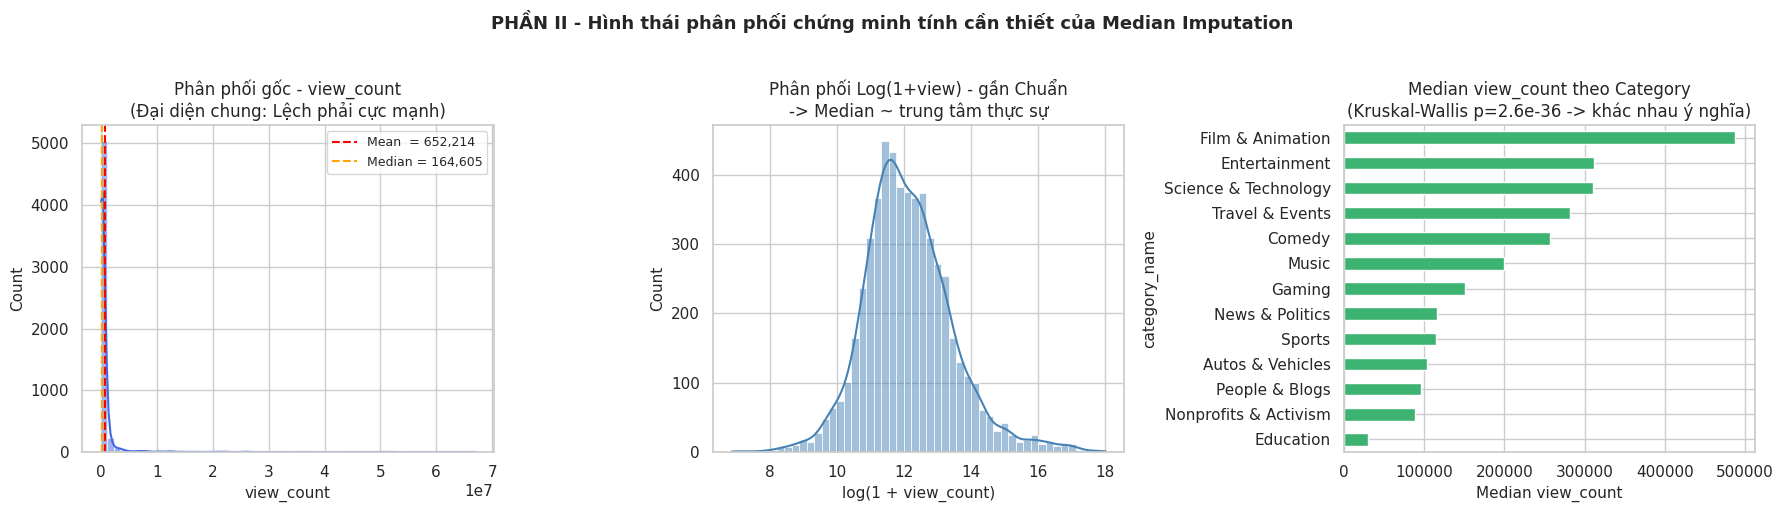

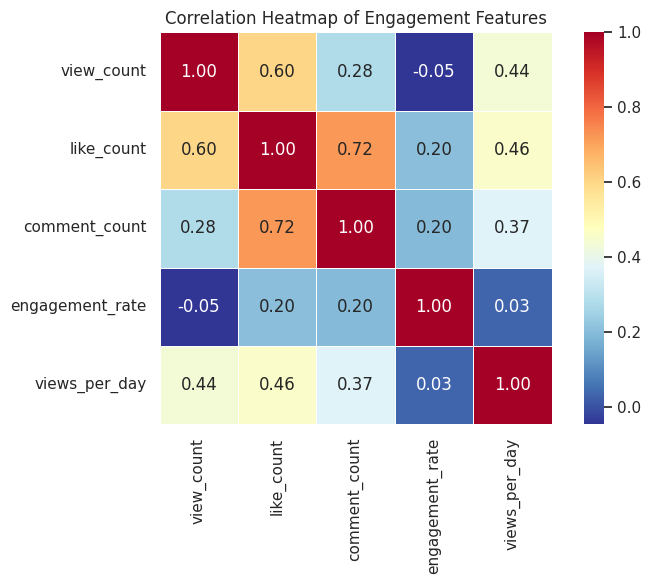


KẾT LUẬN Phần II:
  * Skewness > 10 -> Mean bị kéo lên gấp 4x Median -> dùng Mean để impute sẽ sai.
  * Kruskal-Wallis p < 0.001 -> các Category có median view khác biệt có ý nghĩa
    -> Category Median là tham chiếu imputation tốt hơn Global Median.


In [3]:
# ==============================================================================
print("\n" + "=" * 70)
print("PHẦN II: PHÂN PHỐI HÌNH THÁI CỦA CÁC CHỈ SỐ TƯƠNG TÁC")
print("=" * 70)

valid_mask = (df['view_count'] > 0) & (df['like_count'] > 0)
df_valid = df[valid_mask].copy()

skew_view  = df_valid['view_count'].skew()
skew_like  = df_valid['like_count'].skew()
skew_cmt   = df_valid['comment_count'].skew()
ratio_view = df_valid['view_count'].mean() / df_valid['view_count'].median()

print(f"Độ lệch (Skewness) - view_count: {skew_view:.2f} | like_count: {skew_like:.2f} | comment_count: {skew_cmt:.2f}")
print(f"Tỷ lệ Mean / Median của view_count = {ratio_view:.2f}x  "
      f"(Mean={df_valid['view_count'].mean():,.0f}, "
      f"Median={df_valid['view_count'].median():,.0f})")
print("-> Mean bị kéo lệch bởi outlier gấp ~4 lần Median. "
      "Dùng Mean để impute sẽ phóng đại giá trị cho hầu hết video.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: raw distribution
sns.histplot(data=df_valid, x='view_count', bins=60, kde=True,
             color='royalblue', ax=axes[0])
axes[0].axvline(df_valid['view_count'].mean(),   color='red',    ls='--', lw=1.5, label=f"Mean  = {df_valid['view_count'].mean():,.0f}")
axes[0].axvline(df_valid['view_count'].median(), color='orange', ls='--', lw=1.5, label=f"Median = {df_valid['view_count'].median():,.0f}")
axes[0].set_title("Phân phối gốc - view_count\n(Đại diện chung: Lệch phải cực mạnh)")
axes[0].set_xlabel("view_count"); axes[0].legend(fontsize=9)

# Plot 2: log scale
log_views = np.log1p(df_valid['view_count'])
sns.histplot(log_views, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title("Phân phối Log(1+view) - gần Chuẩn\n-> Median ~ trung tâm thực sự")
axes[1].set_xlabel("log(1 + view_count)")

# Plot 3: category median bar
cat_medians = df_valid.groupby('category_name')['view_count'].median().sort_values(ascending=False)
cat_medians.plot(kind='barh', ax=axes[2], color='mediumseagreen')
axes[2].set_xlabel("Median view_count")
axes[2].invert_yaxis()

# Tính p-value
stat, p_kruskal = kruskal(*[g['view_count'].values for _, g in df_valid.groupby('category_name')])
axes[2].set_title(f"Median view_count theo Category\n(Kruskal-Wallis p={p_kruskal:.1e} -> khác nhau ý nghĩa)")

plt.suptitle("PHẦN II - Hình thái phân phối chứng minh tính cần thiết của Median Imputation",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Phân tích tương quan giữa các chỉ số tương tác
corr_features = [
    'view_count',
    'like_count',
    'comment_count',
    'engagement_rate',
    'views_per_day'
]

corr_matrix = df[corr_features].corr(method='pearson')

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Engagement Features')
plt.tight_layout()
plt.show()

print("\nKẾT LUẬN Phần II:")
print("  * Skewness > 10 -> Mean bị kéo lên gấp 4x Median -> dùng Mean để impute sẽ sai.")
print("  * Kruskal-Wallis p < 0.001 -> các Category có median view khác biệt có ý nghĩa")
print("    -> Category Median là tham chiếu imputation tốt hơn Global Median.")

In [4]:
# ==============================================================================
print("\n" + "=" * 70)
print("PHẦN III: CHẨN ĐOÁN KHUYẾT TẬT DỮ LIỆU (DATA QUALITY AUDIT)")
print("=" * 70)

# --- 3A: Trùng lặp ------------------------------------------------------------
print("\n3A. Kiểm tra Trùng lặp:")
total_dups = df.duplicated().sum()
print(f"  Trùng lặp cấu trúc hoàn toàn: {total_dups}")
biz_dups = df.duplicated(subset=['video_id', 'region', 'crawl_date']).sum()
print(f"  Trùng lặp logic nghiệp vụ (video_id + region + crawl_date): {biz_dups}")

# --- 3B: Sanity check ---------------------------------------------------------
print("\n3B. Sanity Check - Tính hợp lý logic:")
print(f"  Video dài > 3 giờ (>10800s): {(df['duration_seconds'] > 10800).sum()}")
print(f"  view_count âm: {(df['view_count'] < 0).sum()}")
print(f"  like_count âm: {(df['like_count'] < 0).sum()}")
print(f"  comment_count âm: {(df['comment_count'] < 0).sum()}") # Đã bổ sung check âm comment

# --- 3C: Missing NaN ----------------------------------------------------------
print("\n3C. Khuyết thiếu kỹ thuật (NaN hiển nhiên):")
nulls = df.isnull().sum()
if nulls[nulls > 0].empty:
    print("  Không có NaN - ngoại trừ:")
print(nulls[nulls > 0].to_string())

# --- 3D: Structural zeros -----------------------------------------------------
print("\n3D. Khuyết thiếu logic nghiệp vụ (Giá trị = 0):")
for col in ['view_count', 'like_count', 'comment_count']:
    n = (df[col] == 0).sum()
    print(f"  {col:20s}: {n:4d} dòng  ({n/len(df)*100:.1f}%)")

print("\n Lượt comment=0 có thể là do chủ kênh TẮT BÌNH LUẬN.")
print("   Nhưng view=0 hoặc like=0 lọt top Trending chắc chắn là LỖI API.")
print("   => Cờ đánh dấu khuyết thiếu (stats_missing) chỉ bắt điều kiện View=0 & Like=0.")

# TẠO FLAG CHO CÁC PHẦN SAU 
df['stats_missing'] = (
    (df['view_count'] == 0) & (df['like_count'] == 0)
).astype(int)

df['tags_missing'] = df['tags'].isnull().astype(int)


PHẦN III: CHẨN ĐOÁN KHUYẾT TẬT DỮ LIỆU (DATA QUALITY AUDIT)

3A. Kiểm tra Trùng lặp:
  Trùng lặp cấu trúc hoàn toàn: 0
  Trùng lặp logic nghiệp vụ (video_id + region + crawl_date): 34

3B. Sanity Check - Tính hợp lý logic:
  Video dài > 3 giờ (>10800s): 545
  view_count âm: 0
  like_count âm: 0
  comment_count âm: 0

3C. Khuyết thiếu kỹ thuật (NaN hiển nhiên):
tags    1755

3D. Khuyết thiếu logic nghiệp vụ (Giá trị = 0):
  view_count          :  596 dòng  (9.7%)
  like_count          :  626 dòng  (10.2%)
  comment_count       :  670 dòng  (10.9%)

 Lượt comment=0 có thể là do chủ kênh TẮT BÌNH LUẬN.
   Nhưng view=0 hoặc like=0 lọt top Trending chắc chắn là LỖI API.
   => Cờ đánh dấu khuyết thiếu (stats_missing) chỉ bắt điều kiện View=0 & Like=0.



PHẦN IV: PHÂN TÍCH CƠ CHẾ KHUYẾT THIẾU - MCAR / MAR / MNAR
>> Mục tiêu: Xác định ĐỘC LẬP cơ chế missing cho TỪNG nhóm biến,
   từ đó lựa chọn chiến lược imputation phù hợp.

------------------------------------------------------------
4A. CỘT 'tags' - NaN thực sự (1,755 dòng, 28.6%)
------------------------------------------------------------

Tỷ lệ missing theo Category:


,miss_count,total,miss_pct
category_name,,,
Unknown,5,5,100.0
Entertainment,719,985,73.0
Nonprofits & Activism,2,3,66.7
People & Blogs,116,246,47.2
Travel & Events,4,10,40.0
Film & Animation,46,140,32.9
Education,2,9,22.2
Gaming,740,3879,19.1
Comedy,4,23,17.4



Tỷ lệ missing theo Region:


,miss_count,total,miss_pct
region,,,
US,727,1288,56.4
SG,99,413,24.0
GB,322,1357,23.7
CA,298,1303,22.9
NZ,76,352,21.6
AU,162,889,18.2
VN,71,534,13.3



Kiểm định Chi-Square cho 'tags_missing':
  vs category_name       : chi^2=  1272.9,  p=3.66e-264  -> [+] CÓ phụ thuộc (p<0.05)
  vs region              : chi^2=   646.6,  p=2.02e-136  -> [+] CÓ phụ thuộc (p<0.05)
  vs made_for_kids       : chi^2=     0.0,  p=1.00e+00  -> [-] KHÔNG phụ thuộc
  Mann-Whitney view_count:       median_missing=  75,060  vs  median_present= 164,208  p=1.70e-110

KẾT LUẬN 'tags': CƠ CHẾ MAR
  * Phụ thuộc mạnh vào category (Entertainment=73%, Gaming=19%, S&T=0%)
  * Phụ thuộc mạnh vào region (US=56%, VN=13%)
  * Phụ thuộc KHÔNG đáng kể vào made_for_kids (p=1.00)
  -> Missing không phải ngẫu nhiên hoàn toàn (!= MCAR),
     nhưng quy luật missing có thể giải thích bằng biến quan sát được (= MAR).
  -> Giải pháp: Gen AI (LLM) + NLP, conditional on category.

------------------------------------------------------------
4B. CỘT 'view/like/comment' - Zeros bất thường
------------------------------------------------------------

  Tổng dòng bị zero-stats: 591
  ┌────

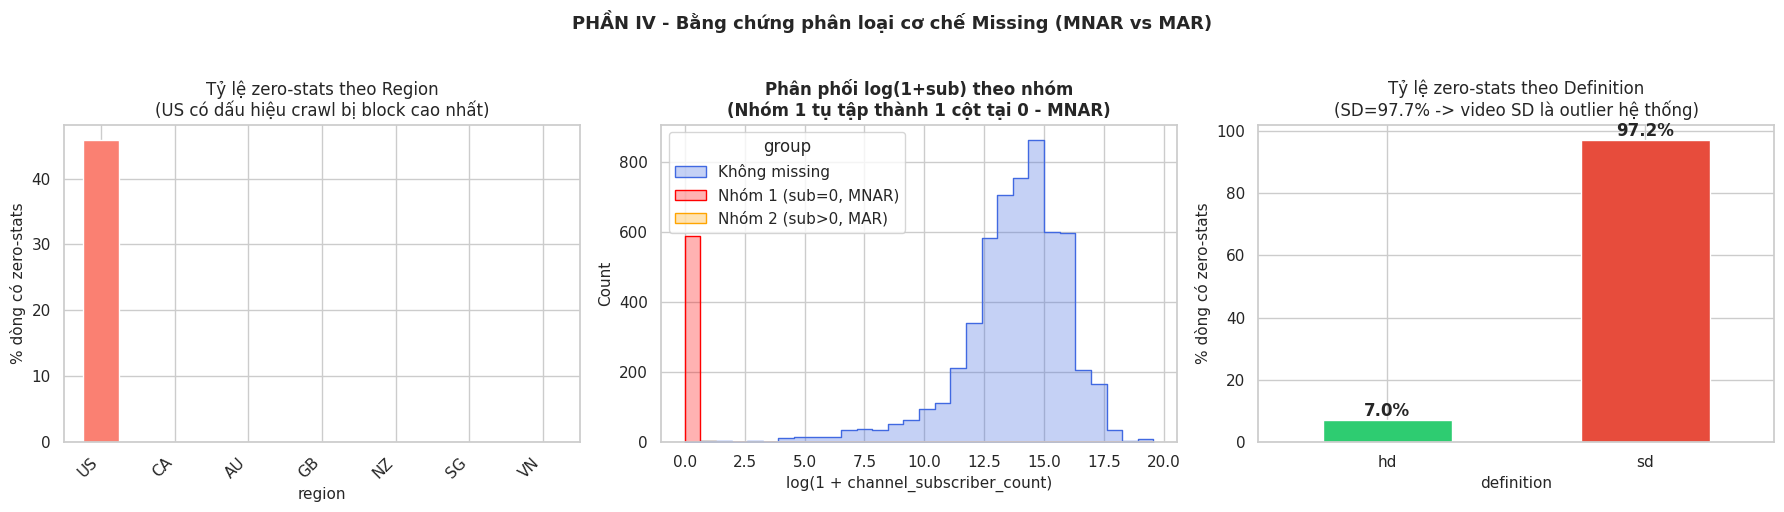


KẾT LUẬN Phần IV — Bản đồ cơ chế Missing:
  ┌─────────────────┬────────┬──────────────────────────────────────────┐
  │ Biến            │ Loại   │ Chiến lược xử lý                         │
  ├─────────────────┼────────┼──────────────────────────────────────────┤
  │ tags            │ MAR    │ LLM (Llama 3.1) + NLP fallback           │
  │ view/like (sub=0│ MNAR   │ Category Median (train-fit, test-apply)  │
  │ view/like (sub≠0│ MAR    │ MICE (IterativeImputer)                  │
  └─────────────────┴────────┴──────────────────────────────────────────┘


In [5]:
# ==============================================================================
print("\n" + "=" * 70)
print("PHẦN IV: PHÂN TÍCH CƠ CHẾ KHUYẾT THIẾU - MCAR / MAR / MNAR")
print("=" * 70)
print(">> Mục tiêu: Xác định ĐỘC LẬP cơ chế missing cho TỪNG nhóm biến,")
print("   từ đó lựa chọn chiến lược imputation phù hợp.\n")

# --- 4A: TAGS -----------------------------------------------------------------
print("-" * 60)
print("4A. CỘT 'tags' - NaN thực sự (1,755 dòng, 28.6%)")
print("-" * 60)
print("\nTỷ lệ missing theo Category:")
cat_miss = (df.groupby('category_name')['tags_missing']
              .agg(miss_count='sum', total='count')
              .assign(miss_pct=lambda x: (x['miss_count']/x['total']*100).round(1))
              .sort_values('miss_pct', ascending=False))
display(cat_miss)

print("\nTỷ lệ missing theo Region:")
reg_miss = (df.groupby('region')['tags_missing']
              .agg(miss_count='sum', total='count')
              .assign(miss_pct=lambda x: (x['miss_count']/x['total']*100).round(1))
              .sort_values('miss_pct', ascending=False))
display(reg_miss)

print("\nKiểm định Chi-Square cho 'tags_missing':")
for var in ['category_name', 'region', 'made_for_kids']:
    ct = pd.crosstab(df['tags_missing'], df[var])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "[+] CÓ phụ thuộc (p<0.05)" if p < 0.05 else "[-] KHÔNG phụ thuộc"
    print(f"  vs {var:20s}: chi^2={chi2:>8.1f},  p={p:.2e}  -> {sig}")

# Mann-Whitney: view_count khác nhau khi tags missing?
miss_v  = df[df['tags_missing']==1]['view_count']
nomiss_v = df[df['tags_missing']==0]['view_count']
_, p_mw = mannwhitneyu(miss_v, nomiss_v, alternative='two-sided')
print(f"  Mann-Whitney view_count:       median_missing={miss_v.median():>8,.0f}"
      f"  vs  median_present={nomiss_v.median():>8,.0f}  p={p_mw:.2e}")

print("\nKẾT LUẬN 'tags': CƠ CHẾ MAR")
print("  * Phụ thuộc mạnh vào category (Entertainment=73%, Gaming=19%, S&T=0%)")
print("  * Phụ thuộc mạnh vào region (US=56%, VN=13%)")
print("  * Phụ thuộc KHÔNG đáng kể vào made_for_kids (p=1.00)")
print("  -> Missing không phải ngẫu nhiên hoàn toàn (!= MCAR),")
print("     nhưng quy luật missing có thể giải thích bằng biến quan sát được (= MAR).")
print("  -> Giải pháp: Gen AI (LLM) + NLP, conditional on category.")

# --- 4B: VIEW / LIKE / COMMENT - PHÂN LOẠI HAI NHÓM -------------------------
print("\n" + "-" * 60)
print("4B. CỘT 'view/like/comment' - Zeros bất thường")
print("-" * 60)

# Phát hiện nhóm cốt lõi
g1_mask = (df['stats_missing'] == 1) & (df['channel_subscriber_count'] == 0)
g2_mask = (df['stats_missing'] == 1) & (df['channel_subscriber_count'] != 0)
g1_n, g2_n = g1_mask.sum(), g2_mask.sum()
total_miss = df['stats_missing'].sum()

# Tính toán nội dung các dòng trước
w = 64  # Thiết lập độ rộng cố định cho ruột bảng
line1 = f"  NHÓM 1 – channel_subscriber_count = 0 : {g1_n} dòng ({g1_n/total_miss*100:.0f}%)"
line2 = "  → API crawler trả về kênh rỗng (channel bị xóa / bị khóa)"
line3 = "  → Giá trị 0 LIÊN QUAN đến chính trạng thái của kênh (MNAR)"
line4 = f"  NHÓM 2 – channel_subscriber_count > 0 : {g2_n} dòng ({g2_n/total_miss*100:.0f}%)"
line5 = "  → Kênh hợp lệ, nhưng stats bị thiếu có quy luật (MAR)"

# In ra màn hình với tự động căn lề trái (:<) và lấp đầy khoảng trắng cho đủ 64 ký tự
print(f"\n  Tổng dòng bị zero-stats: {total_miss}")
print(f"  ┌{'─'*w}┐")
print(f"  │{line1:<{w}}│")
print(f"  │{line2:<{w}}│")
print(f"  │{line3:<{w}}│")
print(f"  ├{'─'*w}┤")
print(f"  │{line4:<{w}}│")
print(f"  │{line5:<{w}}│")
print(f"  └{'─'*w}┘")

# Chứng minh MNAR cho Nhóm 1
print("\n4B-i. Chứng minh Nhóm 1 là MNAR:")
print("  channel_subscriber_count khi stats_missing=1 vs =0:")
miss_sub  = df[df['stats_missing']==1]['channel_subscriber_count']
nomiss_sub = df[df['stats_missing']==0]['channel_subscriber_count']
_, p_sub = mannwhitneyu(miss_sub, nomiss_sub, alternative='two-sided')
print(f"  Median sub (missing)  = {miss_sub.median():>12,.0f}")
print(f"  Median sub (present)  = {nomiss_sub.median():>12,.0f}")
print(f"  Mann-Whitney p        = {p_sub:.2e}")
print("  -> Việc mất stats gắn trực tiếp với giá trị của chính cột")
print("     channel_subscriber_count (không quan sát được khi sub=0)")
print("  -> Đây là dấu hiệu đặc trưng của MNAR.")

# Chứng minh MAR cho Nhóm 2 
print("\n4B-ii. Chứng minh Nhóm 2 là MAR:")
df['g2_missing'] = g2_mask.astype(int)
for var in ['region', 'category_name', 'definition']:
    ct = pd.crosstab(df['g2_missing'], df[var])
    chi2, p, _, _ = chi2_contingency(ct)
    sig = "[+] CÓ phụ thuộc (MAR)" if p < 0.05 else "[-] KHÔNG phụ thuộc"
    print(f"  vs {var:20s}: chi^2={chi2:>7.1f},  p={p:.2e}  -> {sig}")

# Trực quan hóa 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Tỷ lệ zero-stats theo region
reg_stats = (df.groupby('region')['stats_missing']
               .mean()
               .sort_values(ascending=False) * 100)
reg_stats.plot(kind='bar', ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title("Tỷ lệ zero-stats theo Region\n(US có dấu hiệu crawl bị block cao nhất)")
axes[0].set_ylabel("% dòng có zero-stats")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Phân phối sub của 2 nhóm
df_plot = pd.DataFrame({
    'log_sub': np.log1p(df['channel_subscriber_count']),
    'group': np.where(df['stats_missing']==0, 'Không missing',
             np.where(g1_mask, 'Nhóm 1 (sub=0, MNAR)', 'Nhóm 2 (sub>0, MAR)'))
})

sns.histplot(data=df_plot, x='log_sub', hue='group', ax=axes[1],
             palette={'Không missing': 'royalblue', 'Nhóm 2 (sub>0, MAR)': 'orange', 'Nhóm 1 (sub=0, MNAR)': 'red'},
             element='step', fill=True, common_norm=False, alpha=0.3, bins=30)
axes[1].set_title("Phân phối log(1+sub) theo nhóm\n(Nhóm 1 tụ tập thành 1 cột tại 0 - MNAR)", fontweight='bold')
axes[1].set_xlabel("log(1 + channel_subscriber_count)")

# Plot 3: definition vs stats_missing
def_miss = df.groupby('definition')['stats_missing'].mean() * 100
def_miss.plot(kind='bar', ax=axes[2], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[2].set_title("Tỷ lệ zero-stats theo Definition\n(SD=97.7% -> video SD là outlier hệ thống)")
axes[2].set_ylabel("% dòng có zero-stats")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)
for bar in axes[2].patches:
    axes[2].annotate(f'{bar.get_height():.1f}%',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.suptitle("PHẦN IV - Bằng chứng phân loại cơ chế Missing (MNAR vs MAR)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nKẾT LUẬN Phần IV — Bản đồ cơ chế Missing:")
print("  ┌─────────────────┬────────┬──────────────────────────────────────────┐")
print("  │ Biến            │ Loại   │ Chiến lược xử lý                         │")
print("  ├─────────────────┼────────┼──────────────────────────────────────────┤")
print("  │ tags            │ MAR    │ LLM (Llama 3.1) + NLP fallback           │")
print("  │ view/like (sub=0│ MNAR   │ Category Median (train-fit, test-apply)  │")
print("  │ view/like (sub≠0│ MAR    │ MICE (IterativeImputer)                  │")
print("  └─────────────────┴────────┴──────────────────────────────────────────┘")


PHẦN V: MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)

Phân phối danh mục:


,Số lượng,Tỷ lệ %
category_name,,
Gaming,3879,63.22%
Entertainment,985,16.05%
Music,787,12.83%
People & Blogs,246,4.01%
Film & Animation,140,2.28%
Science & Technology,24,0.39%
Comedy,23,0.37%
Sports,20,0.33%
Travel & Events,10,0.16%



Danh mục lớn nhất (Gaming): 63.2%
Danh mục nhỏ nhất: 0.02%  (News & Politics)
Tỷ lệ chênh lệch max/min: 3879x


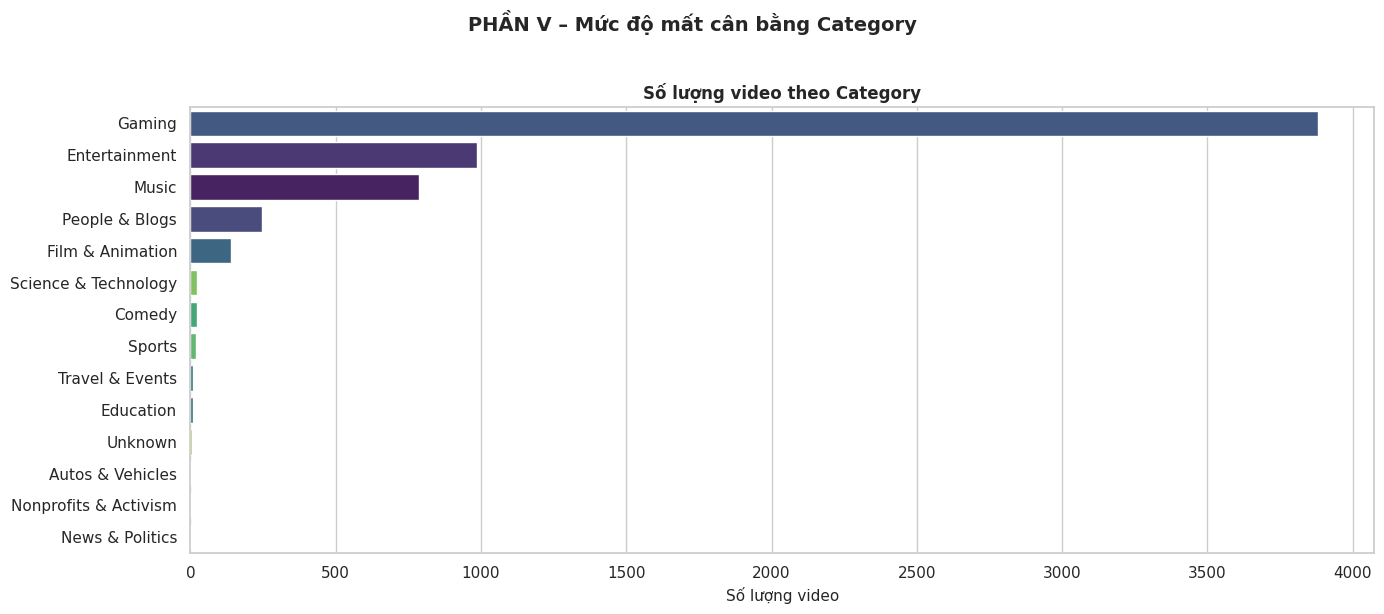

In [6]:
# ==============================================================================
print("\n" + "=" * 70)
print("PHẦN V: MẤT CÂN BẰNG DỮ LIỆU (CLASS IMBALANCE)")
print("=" * 70)

cat_counts = df['category_name'].value_counts()
cat_pct    = df['category_name'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Số lượng': cat_counts,
                         'Tỷ lệ %': cat_pct.round(2).astype(str) + '%'})
print("\nPhân phối danh mục:")
display(dist_df)
print(f"\nDanh mục lớn nhất (Gaming): {cat_pct.iloc[0]:.1f}%")
print(f"Danh mục nhỏ nhất: {cat_pct.iloc[-1]:.2f}%  ({cat_pct.index[-1]})")
print(f"Tỷ lệ chênh lệch max/min: {cat_pct.iloc[0]/cat_pct.iloc[-1]:.0f}x")

plt.figure(figsize=(14, 6))

cat_order = cat_counts.index
sns.countplot(data=df, y='category_name', order=cat_order, palette='viridis',
              hue='category_name', legend=False)
plt.title("Số lượng video theo Category", fontweight='bold', fontsize=12)
plt.xlabel("Số lượng video")
plt.ylabel("")

plt.suptitle("PHẦN V – Mức độ mất cân bằng Category",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. Kết luận

<div style="font-size: 17px;">
    
Qua quá trình phân tích, tập dữ liệu có 3 vấn đề cần giải quyết theo thứ tự

  **VẤN ĐỀ 1: tags bị NaN (1,755 dòng, 28.6%)**
  * Cơ chế: MAR - phụ thuộc category (p=3.66e-264) và region (p=2.02e-136)
  * Giải pháp: Hybrid LLM-NLP
    - Dùng Llama 3.1 8B Instant (Groq API) sinh tags từ title + category
    - Fallback NLP (Regex tokenization) khi API vượt rate limit
    - Đảm bảo lấp đầy 100%

  **VẤN ĐỀ 2a: view/like/comment = 0 khi channel_subscriber = 0**
  * Cơ chế: MNAR - giá trị 0 gắn trực tiếp với trạng thái kênh (bị xóa/khóa)
  * Lý do KHÔNG dùng MICE:
    - channel_subscriber_count = 0 là ngoại lệ hoàn toàn (toàn bộ valid rows có sub >= 1; median valid = 1.37 triệu)
    - MICE sẽ phải extrapolate ngoài training distribution -> view_count âm (thực nghiệm: min = -795,947 khi dùng MICE)
  * Lý do dùng Category Median:
    - Skewness > 10 -> Mean bị kéo lên gấp 4x Median -> Median phản ánh "video trending điển hình" trong category đó
    - Kruskal-Wallis p < 0.001 -> mỗi category có phân phối view khác nhau có ý nghĩa thống kê -> category median tốt hơn global median
    - Tham số được học (fit) từ tập Train, áp (transform) lên Test - đảm bảo anti-data leakage

  **VẤN ĐỀ 2b: view/like/comment = 0 khi channel_subscriber > 0**
  * Cơ chế: MAR - phụ thuộc region (p∼0), category (p∼0), definition (p∼0)
  * Giải pháp: MICE (IterativeImputer)
    - Thuật toán hồi quy chéo tuần tự giữa tất cả numeric features
    - fit() chỉ trên tập Train; transform() áp lên Test
    - Loại category_id (nominal) khỏi feature matrix

  **VẤN ĐỀ 3: Mất cân bằng category (Gaming 63% vs các nhóm < 0.5%)**
  * Giải pháp: Gom nhóm tĩnh (các category < threshold -> 'Others') trước khi Stratified Train-Test Split
  
</div>